<a href="https://colab.research.google.com/github/LeonardooAlves/WM9B7-AIDL/blob/main/Week%202/6_Case_Study_HFT_Fraud_Detection_Challenge_(Pitch).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HFT Fraud Detection Challenge (Pitch)

#### **Objective:** Discuss why LSTMs are superior to RNNs for detecting "Spoofing" in 1,000-trade sequences.

---

## Phase 1: Environment & Data Investigation
**Goal:** Understand the "Crime Scene" (The Dataset).

1.  **Run the Data Generation Cell:** Look at the `generate_hft_data` function.
2.  **Identify the Signal:** Notice that the "Fraud" (y=1) is defined by two distant events:
    * **The Build-up:** A "ladder" of buy orders at steps 100–300.
    * **The Crash:** A massive sell-off at steps 800–950.
3.  **Critical Thinking:** If you only looked at steps 800–950, would the data look fraudulent or just like a normal market dip? *Hint: The fraud is only visible if you remember the "ladder" from 500 steps ago.*





## Phase 2: The Battle of Architectures
**Goal:** Observe the "Vanishing Gradient" problem in real-time.

1.  **Execute the RNN Training:** Watch the loss curve. You will likely see the RNN struggle to move past a certain accuracy (often around 50%—no better than a coin flip).
2.  **Execute the LSTM Training:** Notice how the loss drops more consistently.
3.  **Analyze the Classification Report:** * Look at the **Recall** for the Fraud class (1.0).
    * If the RNN has low recall, it is "forgetting" the start of the trade sequence and missing the fraud entirely.



## Phase 3: Forensic Analysis for your Pitch
**Goal:** Gather the evidence needed to "sell" the LSTM solution to a board of directors.

#### **1. The Memory Stress Test**
In the code, the sequence length is set to $1,000$.
* **Task:** Try changing `seq_length` to $100$ and re-run both models.
* **Observation:** Does the RNN perform better on shorter sequences? Why does it fail as the "time window" grows? Use the term **Vanishing Gradient** in your notes.

#### **2. The Hidden State Logic**
In the PyTorch `forward` function, we use `out[:, -1, :]`.
* **Task:** Explain in your pitch how the LSTM **Cell State** ($c_t$) acts as a "long-term fileserver" while the **Hidden State** ($h_t$) acts as "short-term working memory."





## Phase 4: Structuring Your Pitch
Prepare a 5-minute presentation pitch with your narrative.

In [1]:
# Run this cell to initialize the environment and generate synthetic HFT data.

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, SimpleRNN, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [2]:
# 1. DATA GENERATION: THE "SPOOFING" PATTERN
# We simulate 1,000 micro-transactions.
# Normal: Random walk price fluctuations.
# Fraud: A specific "ladder" of buy orders followed by a sudden massive sell.

def generate_hft_data(n_samples=1000, seq_length=1000):
    X = np.random.randn(n_samples, seq_length, 1)  # Feature: Price Change/Volume
    y = np.zeros(n_samples)

    for i in range(n_samples):
        if np.random.rand() > 0.5:
            # Inject a "Spoofing" pattern: gradual increase in the first 200 steps
            # that the model must "remember" to explain a crash at step 900.
            X[i, 100:300, 0] += np.linspace(0, 2, 200)
            X[i, 800:950, 0] -= 5 # The "Dump"
            y[i] = 1 # Label as Fraud

    return X, y

print("Generating 1,000 sequences of 1,000 trades each...")
X, y = generate_hft_data()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Generating 1,000 sequences of 1,000 trades each...


In [3]:
# ---
# 2. MODEL 1: SIMPLE RNN (The "Short-Term Memory" Baseline)
# ---
print("\nTraining Simple RNN...")
model_rnn = Sequential([
    SimpleRNN(32, input_shape=(1000, 1)),
    Dense(1, activation='sigmoid')
])
model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_rnn = model_rnn.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1, verbose=0)


Training Simple RNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:
# ---
# 3. MODEL 2: LSTM (The "Long-Term Memory" Solution)
# ---
print("Training LSTM...")
model_lstm = Sequential([
    LSTM(32, input_shape=(1000, 1)),
    Dense(1, activation='sigmoid')
])
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_lstm = model_lstm.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1, verbose=0)

Training LSTM...


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step

--- Simple RNN Results ---
              precision    recall  f1-score   support

         0.0       0.50      0.46      0.48        99
         1.0       0.51      0.54      0.53       101

    accuracy                           0.51       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.50      0.51      0.50       200

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

--- LSTM Results ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        99
         1.0       1.00      1.00      1.00       101

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



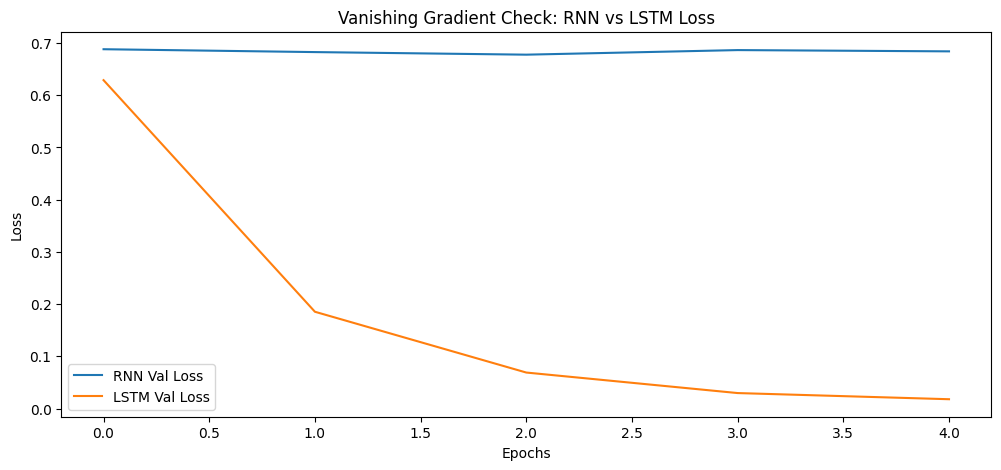

In [5]:
# ---
# 4. EVALUATION & VISUALIZATION
# ---
def evaluate_model(model, name):
    preds = (model.predict(X_test) > 0.5).astype("int32")
    print(f"\n--- {name} Results ---")
    print(classification_report(y_test, preds))

evaluate_model(model_rnn, "Simple RNN")
evaluate_model(model_lstm, "LSTM")

# Plotting Loss
plt.figure(figsize=(12, 5))
plt.plot(history_rnn.history['val_loss'], label='RNN Val Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val Loss')
plt.title('Vanishing Gradient Check: RNN vs LSTM Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## The Case Scenario: Project "Argus"
**Company:** *OmniQuant Capital*, a mid-sized algorithmic trading firm.  
**The Situation:** The firm was recently fined $1.2M by the Financial Conduct Authority (FCA) because their traditional, rule-based systems failed to detect a "Spoofing" event that occurred over a 3-minute window (approx. 5,000 micro-transactions).  
**The Task:** Your team has been hired to replace the old "If/Then" threshold system with a Deep Learning sequence model. You have developed the **LSTM-Argus Prototype** (the code above).

### **The Stakeholder Personas**
Your team must address these two distinct "pain points" in their pitch:
1.  **The Chief Risk Officer (The Skeptic):** Worried about *Interpretability*. "How do I know why the model flagged this? If the regulator asks for an explanation, can the LSTM provide it?"
2.  **The Head of Trading (The Pragmatist):** Worried about *Latency*. "In HFT, every millisecond counts. Does this LSTM slow down our execution engine?"

---

## Required Technical Reading
To back their pitch with academic authority, you must read and cite the following paper (or a similar high-impact study):

**Primary Source:**
* **Paper:** *"DeepLOB: Deep Convolutional Neural Networks for Limit Order Books":* https://arxiv.org/abs/1808.03668.

* **Why this paper?** The authors explain why simple models fail to capture the "dynamics" of the market, providing the academic "weight" your need to convince stakeholders.

---

## Presentation Requirements: The "Production-Ready" Pitch
The presentation must be **10 minutes** long, followed by a **5-minute Q&A** (The "Grilling"). You must use the results to prove the following:

* Show a comparison between the $1,000$-step RNN and LSTM.
* How will the team explain a "Fraud" alert?
* What happens when we start the day and have no history?



*"You are not here to show us your code. You are here to show us why your code is worth a $5 million investment in our production servers. If your LSTM fails to catch the next spoofing event, the company goes under. Prove to us why we should trust the gates."*